#### Redução de dimensionalidade

Colab: https://colab.research.google.com/drive/1lfM1MhacUgsx5Q13vIIMnuKU5qGh5GD6

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 12.7 MB/s eta 0:00:00a 0:00:01



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: /Users/mariolemes/PycharmProjects/pos-NLP/.venv/bin/python -m pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/mariolemes/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mariolemes/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Tokens após remoção de stopwords: [880] ['ontem', 'corri', 'cinco', 'quilômetros', 'parque', 'cachorro', 'começou', 'latir', 'rapidamente', 'corri', 'casa', 'corri', 'rápido', 'pude', 'perder', 'ônibus', 'assim', 'ouvi', 'notícia', 'corri', 'contar', 'amigos', 'escola', 'corri', 'parque', 'encontrar', 'amigos', 'ontem', 'corri', 'cinco', 'quilômetros', 'parque', 'cachorro', 'começou', 'latir', 'rapidamente', 'corri', 'casa', 'corri', 'rápido', 'pude', 'perder', 'ônibus', 'assim', 'ouvi', 'notícia', 'corri', 'contar', 'amigos', 'escola', 'corri', 'parque', 'encontrar', 'amigos', 'ontem', 'corri', 'cinco', 'quilômetros', 'parque', 'cachorro', 'começou', 'latir', 'rapidamente', 'corri', 'casa', 'corri', 'rápido', 'pude', 'perder', 'ônibus', 'assim', 'ouvi', 'notícia', 'corri', 'contar', 'amigos', 'escola', 'corri', 'parque', 'encontrar', 'amigos', 'ontem', 'corri', 'cinco', 'quilômetros', 'parque', 'cachorro', 'começou', 'latir', 'rapidamente', 'corri', 'casa', 'corri', 'rápido', 'pude', 

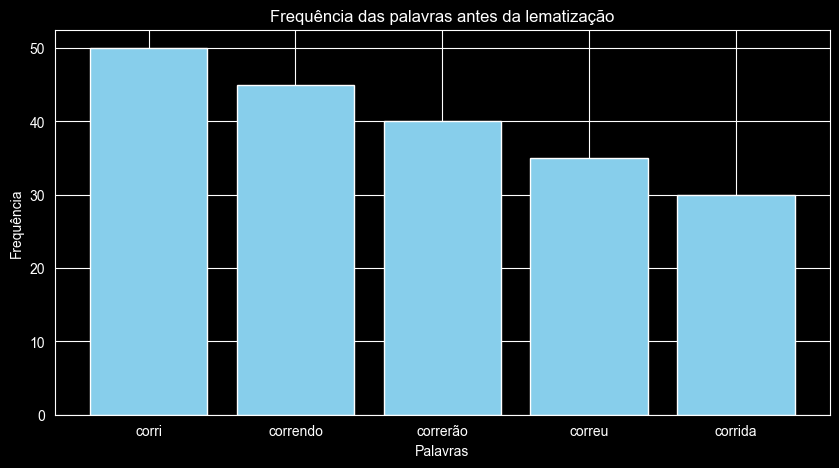

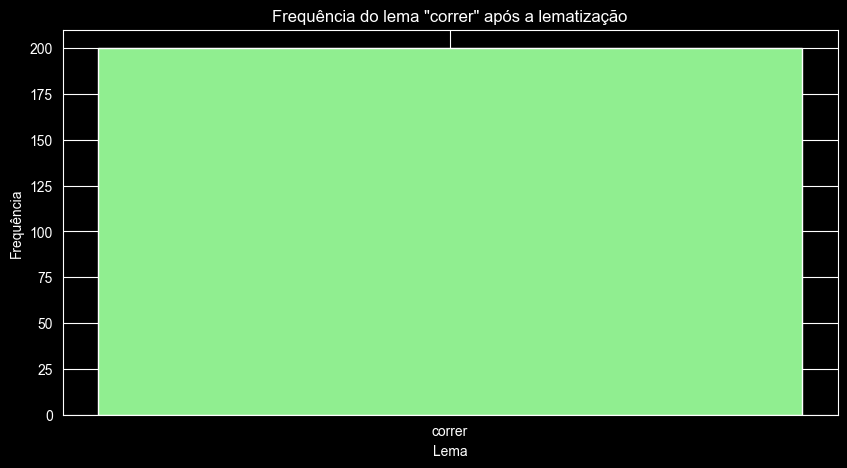


Frequência de palavras antes da lematização:
ontem: 10
corri: 50
cinco: 10
quilômetros: 10
parque: 29
cachorro: 26
começou: 16
latir: 10
rapidamente: 10
casa: 17
rápido: 10
pude: 10
perder: 10
ônibus: 19
assim: 17
ouvi: 10
notícia: 17
contar: 10
amigos: 20
escola: 17
encontrar: 10
correndo: 45
pegar: 16
atletas: 17
volta: 9
pista: 9
vi: 9
grupo: 9
pessoas: 9
crianças: 9
brincando: 9
jardim: 9
atrás: 9
bola: 9
correrão: 40
maratona: 15
próximo: 8
mês: 8
competidores: 8
diferentes: 8
categorias: 8
todos: 14
tempo: 8
primeira: 8
vez: 8
prova: 8
corredores: 8
profissionais: 8
próxima: 8
competição: 8
garoto: 7
correu: 35
atrasar: 7
inteira: 7
parar: 7
ouviu: 7
direção: 7
portão: 7
último: 7
trem: 7
noite: 7
corrida: 30
carros: 6
amanhã: 6
manhã: 12
treinou: 6
hoje: 6
participaram: 6
beneficente: 6
domingo: 6
ansiosos: 6
grande: 6


Frequência de palavras após a lematização:
ontem: 10
correr: 200
cinco: 10
quilômetro: 10
parque: 29
cachorro: 26
começar: 16
latir: 10
rapidamente: 10
cas: 10

In [1]:
# Etapa 1: Verificação e Instalação das Bibliotecas Necessárias
import subprocess
import sys

def install_and_import(package):
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Instalar as bibliotecas necessárias
install_and_import('spacy')


import nltk
import spacy
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import matplotlib.pyplot as plt

# Baixar o modelo de português do spaCy, caso não esteja instalado
subprocess.run([sys.executable, "-m", "spacy", "download", "pt_core_news_sm"])

# Baixar os recursos necessários
nltk.download('punkt')
nltk.download('stopwords')

# Carregar o modelo de linguagem do spaCy para lematização em português
nlp = spacy.load("pt_core_news_sm")

# Conjunto de frases de exemplo em português
frases = [
    """Ontem, eu corri cinco quilômetros no parque."""
    """Quando o cachorro começou a latir, eu rapidamente corri para casa."""
    """Corri o mais rápido que pude para não perder o ônibus."""
    """Assim que ouvi a notícia, corri para contar aos meus amigos."""
    """Depois da escola, corri para o parque encontrar meus amigos."""
    """Ontem, eu corri cinco quilômetros no parque."""
    """Quando o cachorro começou a latir, eu rapidamente corri para casa."""
    """Corri o mais rápido que pude para não perder o ônibus."""
    """Assim que ouvi a notícia, corri para contar aos meus amigos."""
    """Depois da escola, corri para o parque encontrar meus amigos."""
    """Ontem, eu corri cinco quilômetros no parque."""
    """Quando o cachorro começou a latir, eu rapidamente corri para casa."""
    """Corri o mais rápido que pude para não perder o ônibus."""
    """Assim que ouvi a notícia, corri para contar aos meus amigos."""
    """Depois da escola, corri para o parque encontrar meus amigos."""
    """Ontem, eu corri cinco quilômetros no parque."""
    """Quando o cachorro começou a latir, eu rapidamente corri para casa."""
    """Corri o mais rápido que pude para não perder o ônibus."""
    """Assim que ouvi a notícia, corri para contar aos meus amigos."""
    """Depois da escola, corri para o parque encontrar meus amigos."""
    """Ontem, eu corri cinco quilômetros no parque."""
    """Quando o cachorro começou a latir, eu rapidamente corri para casa."""
    """Corri o mais rápido que pude para não perder o ônibus."""
    """Assim que ouvi a notícia, corri para contar aos meus amigos."""
    """Depois da escola, corri para o parque encontrar meus amigos."""
    """Ontem, eu corri cinco quilômetros no parque."""
    """Quando o cachorro começou a latir, eu rapidamente corri para casa."""
    """Corri o mais rápido que pude para não perder o ônibus."""
    """Assim que ouvi a notícia, corri para contar aos meus amigos."""
    """Depois da escola, corri para o parque encontrar meus amigos."""
    """Ontem, eu corri cinco quilômetros no parque."""
    """Quando o cachorro começou a latir, eu rapidamente corri para casa."""
    """Corri o mais rápido que pude para não perder o ônibus."""
    """Assim que ouvi a notícia, corri para contar aos meus amigos."""
    """Depois da escola, corri para o parque encontrar meus amigos."""
    """Ontem, eu corri cinco quilômetros no parque."""
    """Quando o cachorro começou a latir, eu rapidamente corri para casa."""
    """Corri o mais rápido que pude para não perder o ônibus."""
    """Assim que ouvi a notícia, corri para contar aos meus amigos."""
    """Depois da escola, corri para o parque encontrar meus amigos."""
    """Ontem, eu corri cinco quilômetros no parque."""
    """Quando o cachorro começou a latir, eu rapidamente corri para casa."""
    """Corri o mais rápido que pude para não perder o ônibus."""
    """Assim que ouvi a notícia, corri para contar aos meus amigos."""
    """Depois da escola, corri para o parque encontrar meus amigos."""
    """Ontem, eu corri cinco quilômetros no parque."""
    """Quando o cachorro começou a latir, eu rapidamente corri para casa."""
    """Corri o mais rápido que pude para não perder o ônibus."""
    """Assim que ouvi a notícia, corri para contar aos meus amigos."""
    """Depois da escola, corri para o parque encontrar meus amigos."""
    """Ela estava correndo para pegar o ônibus."""
    """Os atletas estão correndo em volta da pista."""
    """Vi um grupo de pessoas correndo no parque."""
    """As crianças estavam correndo e brincando no jardim."""
    """O cachorro estava correndo atrás da bola."""
    """Ela estava correndo para pegar o ônibus."""
    """Os atletas estão correndo em volta da pista."""
    """Vi um grupo de pessoas correndo no parque."""
    """As crianças estavam correndo e brincando no jardim."""
    """O cachorro estava correndo atrás da bola."""
    """Ela estava correndo para pegar o ônibus."""
    """Os atletas estão correndo em volta da pista."""
    """Vi um grupo de pessoas correndo no parque."""
    """As crianças estavam correndo e brincando no jardim."""
    """O cachorro estava correndo atrás da bola."""
    """Ela estava correndo para pegar o ônibus."""
    """Os atletas estão correndo em volta da pista."""
    """Vi um grupo de pessoas correndo no parque."""
    """As crianças estavam correndo e brincando no jardim."""
    """O cachorro estava correndo atrás da bola."""
    """Ela estava correndo para pegar o ônibus."""
    """Os atletas estão correndo em volta da pista."""
    """Vi um grupo de pessoas correndo no parque."""
    """As crianças estavam correndo e brincando no jardim."""
    """O cachorro estava correndo atrás da bola."""
    """Ela estava correndo para pegar o ônibus."""
    """Os atletas estão correndo em volta da pista."""
    """Vi um grupo de pessoas correndo no parque."""
    """As crianças estavam correndo e brincando no jardim."""
    """O cachorro estava correndo atrás da bola."""
    """Ela estava correndo para pegar o ônibus."""
    """Os atletas estão correndo em volta da pista."""
    """Vi um grupo de pessoas correndo no parque."""
    """As crianças estavam correndo e brincando no jardim."""
    """O cachorro estava correndo atrás da bola."""
    """Ela estava correndo para pegar o ônibus."""
    """Os atletas estão correndo em volta da pista."""
    """Vi um grupo de pessoas correndo no parque."""
    """As crianças estavam correndo e brincando no jardim."""
    """O cachorro estava correndo atrás da bola."""
    """Ela estava correndo para pegar o ônibus."""
    """Os atletas estão correndo em volta da pista."""
    """Vi um grupo de pessoas correndo no parque."""
    """As crianças estavam correndo e brincando no jardim."""
    """O cachorro estava correndo atrás da bola."""
    """Eles correrão na maratona no próximo mês."""
    """Os competidores correrão em diferentes categorias."""
    """Todos os atletas correrão ao mesmo tempo."""
    """Eles correrão pela primeira vez na prova."""
    """Os corredores profissionais correrão na próxima competição."""
    """Eles correrão na maratona no próximo mês."""
    """Os competidores correrão em diferentes categorias."""
    """Todos os atletas correrão ao mesmo tempo."""
    """Eles correrão pela primeira vez na prova."""
    """Os corredores profissionais correrão na próxima competição."""
    """Eles correrão na maratona no próximo mês."""
    """Os competidores correrão em diferentes categorias."""
    """Todos os atletas correrão ao mesmo tempo."""
    """Eles correrão pela primeira vez na prova."""
    """Os corredores profissionais correrão na próxima competição."""
    """Eles correrão na maratona no próximo mês."""
    """Os competidores correrão em diferentes categorias."""
    """Todos os atletas correrão ao mesmo tempo."""
    """Eles correrão pela primeira vez na prova."""
    """Os corredores profissionais correrão na próxima competição."""
    """Eles correrão na maratona no próximo mês."""
    """Os competidores correrão em diferentes categorias."""
    """Todos os atletas correrão ao mesmo tempo."""
    """Eles correrão pela primeira vez na prova."""
    """Os corredores profissionais correrão na próxima competição."""
    """Eles correrão na maratona no próximo mês."""
    """Os competidores correrão em diferentes categorias."""
    """Todos os atletas correrão ao mesmo tempo."""
    """Eles correrão pela primeira vez na prova."""
    """Os corredores profissionais correrão na próxima competição."""
    """Eles correrão na maratona no próximo mês."""
    """Os competidores correrão em diferentes categorias."""
    """Todos os atletas correrão ao mesmo tempo."""
    """Eles correrão pela primeira vez na prova."""
    """Os corredores profissionais correrão na próxima competição."""
    """Eles correrão na maratona no próximo mês."""
    """Os competidores correrão em diferentes categorias."""
    """Todos os atletas correrão ao mesmo tempo."""
    """Eles correrão pela primeira vez na prova."""
    """Os corredores profissionais correrão na próxima competição."""
    """O garoto correu para a escola para não se atrasar."""
    """Ele correu a maratona inteira sem parar."""
    """Assim que ouviu a notícia, correu para casa."""
    """O cachorro correu em direção ao portão."""
    """Ela correu para pegar o último trem da noite."""
    """O garoto correu para a escola para não se atrasar."""
    """Ele correu a maratona inteira sem parar."""
    """Assim que ouviu a notícia, correu para casa."""
    """O cachorro correu em direção ao portão."""
    """Ela correu para pegar o último trem da noite."""
    """O garoto correu para a escola para não se atrasar."""
    """Ele correu a maratona inteira sem parar."""
    """Assim que ouviu a notícia, correu para casa."""
    """O cachorro correu em direção ao portão."""
    """Ela correu para pegar o último trem da noite."""
    """O garoto correu para a escola para não se atrasar."""
    """Ele correu a maratona inteira sem parar."""
    """Assim que ouviu a notícia, correu para casa."""
    """O cachorro correu em direção ao portão."""
    """Ela correu para pegar o último trem da noite."""
    """O garoto correu para a escola para não se atrasar."""
    """Ele correu a maratona inteira sem parar."""
    """Assim que ouviu a notícia, correu para casa."""
    """O cachorro correu em direção ao portão."""
    """Ela correu para pegar o último trem da noite."""
    """O garoto correu para a escola para não se atrasar."""
    """Ele correu a maratona inteira sem parar."""
    """Assim que ouviu a notícia, correu para casa."""
    """O cachorro correu em direção ao portão."""
    """Ela correu para pegar o último trem da noite."""
    """O garoto correu para a escola para não se atrasar."""
    """Ele correu a maratona inteira sem parar."""
    """Assim que ouviu a notícia, correu para casa."""
    """O cachorro correu em direção ao portão."""
    """Ela correu para pegar o último trem da noite."""
    """A corrida de carros será amanhã de manhã."""
    """Ela treinou muito para a corrida de hoje."""
    """A corrida começou às 7 da manhã."""
    """Eles participaram da corrida beneficente no domingo."""
    """Todos estavam ansiosos pela grande corrida."""
    """A corrida de carros será amanhã de manhã."""
    """Ela treinou muito para a corrida de hoje."""
    """A corrida começou às 7 da manhã."""
    """Eles participaram da corrida beneficente no domingo."""
    """Todos estavam ansiosos pela grande corrida."""
    """A corrida de carros será amanhã de manhã."""
    """Ela treinou muito para a corrida de hoje."""
    """A corrida começou às 7 da manhã."""
    """Eles participaram da corrida beneficente no domingo."""
    """Todos estavam ansiosos pela grande corrida."""
    """A corrida de carros será amanhã de manhã."""
    """Ela treinou muito para a corrida de hoje."""
    """A corrida começou às 7 da manhã."""
    """Eles participaram da corrida beneficente no domingo."""
    """Todos estavam ansiosos pela grande corrida."""
    """A corrida de carros será amanhã de manhã."""
    """Ela treinou muito para a corrida de hoje."""
    """A corrida começou às 7 da manhã."""
    """Eles participaram da corrida beneficente no domingo."""
    """Todos estavam ansiosos pela grande corrida."""
    """A corrida de carros será amanhã de manhã."""
    """Ela treinou muito para a corrida de hoje."""
    """A corrida começou às 7 da manhã."""
    """Eles participaram da corrida beneficente no domingo."""
    """Todos estavam ansiosos pela grande corrida."""
    ]

# Função para substituir pontuação e números por espaços
def substituir_pontuacao_numeros(frase):
    tabela_traducao = str.maketrans(string.punctuation + '0123456789', ' ' * (len(string.punctuation) + 10))
    return frase.translate(tabela_traducao)

# Função para processar cada frase
def processar_frase(frase):
    # Substituir pontuação e números por espaços
    frase_limpa = substituir_pontuacao_numeros(frase)

    # Tokenização
    tokens = word_tokenize(frase_limpa)

    # Remoção de stopwords
    stop_words = set(stopwords.words('portuguese'))
    # len(stopwords) = 207, exemplos:
    #{'pela', 'quando', 'há', 'estiver', 'mais', 'fomos', 'hajamos', 'esta',
    # 'esteve', 'tivéssemos', 'dos', 'houvesse', 'estas', 'eu', 'houveremos',
    # 'pelos', 'serão', 'tiveram', 'tua', 'tivessem', 'tém', 'teríamos', 'terão',
    # 'ele', 'houver', 'estava', 'depois', 'minhas', 'sejamos', 'tu', 'já', 'da',
    #'teriam', 'tivera', 'este', 'por', 'era', 'isto', 'forem', 'na',
    # ....
    #}
    tokens_sem_stopwords = [token for token in tokens if token.lower() not in stop_words]

    # Lematização com substituição manual
    doc = nlp(" ".join(tokens_sem_stopwords))
    tokens_lematizados = []
    for token in doc:
        if token.text.lower() in ["corri", "corrida", "correndo", "correu", "correrão"]:
            tokens_lematizados.append("correr")
        else:
            tokens_lematizados.append(token.lemma_)

    # Criar a lista de lemas únicos
    lemas_unicos = list(set(tokens_lematizados))

    return tokens_sem_stopwords, tokens_lematizados, lemas_unicos

# Processar cada frase no conjunto e calcular frequências
frequencia_original = Counter()
frequencia_lematizada = Counter()

for frase in frases:
    tokens_sem_stopwords, tokens_lematizados, lemas_unicos = processar_frase(frase.lower())

    frequencia_original.update(tokens_sem_stopwords)
    frequencia_lematizada.update(tokens_lematizados)

# Lista de palavras de interesse para o lema "correr"
palavras_interesse_lema = ["correr"]

# Dados de frequência das palavras antes da lematização
palavras = ["corri", "correndo", "correrão", "correu", "corrida"]
frequencias = []

for i in palavras:
    frequencias.append(frequencia_original[i])


print(f"Tokens após remoção de stopwords: [{len(tokens_sem_stopwords)}] {tokens_sem_stopwords}")
print(f"Tokens lematizados:  [{len(tokens_lematizados)}]{tokens_lematizados}")
print(f"Lemas únicos:  [{len(lemas_unicos)}]{lemas_unicos}\n")


# Dados de frequência para o lema "correr" após a lematização
lema = ["correr"]
frequencia_lema = frequencia_lematizada["correr"]

# Gráfico de barras para as palavras antes da lematização
plt.figure(figsize=(10, 5))
plt.bar(palavras, frequencias, color='skyblue')
plt.xlabel('Palavras')
plt.ylabel('Frequência')
plt.title('Frequência das palavras antes da lematização')
plt.show()

# Gráfico de barras para o lema "correr" após a lematização
plt.figure(figsize=(10, 5))
plt.bar(lema, frequencia_lema, color='lightgreen')
plt.xlabel('Lema')
plt.ylabel('Frequência')
plt.title('Frequência do lema "correr" após a lematização')
plt.show()


# Caso queira viisualizar as frequência de cada token,
# remova os comentários as linhas a seguir
#
print("\nFrequência de palavras antes da lematização:")
for palavra, frequencia in frequencia_original.items():
    print(f"{palavra}: {frequencia}")

print("\n\nFrequência de palavras após a lematização:")
for palavra, frequencia in frequencia_lematizada.items():
    print(f"{palavra}: {frequencia}")
